#swiggy and zomato food delivary analysis

In [20]:

import pandas as pd
import matplotlib.pyplot as plt

df=pd.DataFrame(
    {
        "order time": [10, 1, 2, 3, 4, 3, 6],
        "delivery time": [15, 12, 42, 64, 26, 45, 23],
        "delivary partner": ["mohan","harsha","shannu","vardhan","kumar","lokesh","raja"],
        "areas":["a","b","c","d","e","f","g"],
        "customer ratings": [5,3,5,2,1,4,3]
    }
)
df

#average delivery time
avg_delivery_time = df['delivery time'].mean()
print(f"\nAverage delivery time: {avg_delivery_time:.2f} minutes")

#peak order hours
peak_hours = df['order time'].value_counts().idxmax()
print(f"\nPeak order hours: {peak_hours}")

#most delayed area
most_delayed_area = df.groupby('areas')['delivery time'].mean().idxmax()
print(f"\nMost delayed area: {most_delayed_area}")

#top rated delivary partners
top_rated_partners = df.groupby('delivary partner')['customer ratings'].mean().nlargest(3)
print("\nTop rated delivary partners:")
print(top_rated_partners)




Average delivery time: 32.43 minutes

Peak order hours: 3

Most delayed area: d

Top rated delivary partners:
delivary partner
mohan     5.0
shannu    5.0
lokesh    4.0
Name: customer ratings, dtype: float64


In [21]:
#performance report
print("\nPerformance Report:")
print(df)
# Average customer rating
avg_rating = df['customer ratings'].mean()
print(f"\nAverage Customer Rating: {avg_rating:.2f}")

# Areas with low ratings
low_rated_areas = df.groupby('areas')['customer ratings'].mean().nsmallest(3)
print("\nAreas with Lowest Ratings:")
print(low_rated_areas)

# Delivery partners with low ratings
low_rated_partners = df.groupby('delivary partner')['customer ratings'].mean().nsmallest(3)
print("\nDelivery Partners with Lowest Ratings:")
print(low_rated_partners)



Performance Report:
   order time  delivery time delivary partner areas  customer ratings
0          10             15            mohan     a                 5
1           1             12           harsha     b                 3
2           2             42           shannu     c                 5
3           3             64          vardhan     d                 2
4           4             26            kumar     e                 1
5           3             45           lokesh     f                 4
6           6             23             raja     g                 3

Average Customer Rating: 3.29

Areas with Lowest Ratings:
areas
e    1.0
d    2.0
b    3.0
Name: customer ratings, dtype: float64

Delivery Partners with Lowest Ratings:
delivary partner
kumar      1.0
vardhan    2.0
harsha     3.0
Name: customer ratings, dtype: float64


In [22]:
print("\n--- Recommendations for Delivery Partners ---")
for index, row in df.iterrows():
    partner_name = row['delivary partner']
    delivery_time = row['delivery time']
    order_time = row['order time']
    customer_rating = row['customer ratings']

    print(f"\nDelivery Partner: {partner_name} (Current Rating: {customer_rating} stars)")

    if delivery_time < avg_delivery_time and order_time == peak_hours:
        print("Current Status: Excellent performance. Maintain fast delivery during peak hours.")
    elif delivery_time < avg_delivery_time and order_time != peak_hours:
        print("Current Status: Good performance with fast delivery. Focus on maintaining speed, especially during peak hours to achieve 5 stars.")
    elif delivery_time > avg_delivery_time and order_time == peak_hours:
        print("Current Status: Delivery time is slower than average, despite being during peak hours. Prioritize faster delivery during peak times to avoid customer dissatisfaction.")
    else:
        print("Current Status: Delivery time is slower than average and not during peak hours. This combination leads to customer dissatisfaction. Aim for faster deliveries and better time management.")


--- Recommendations for Delivery Partners ---

Delivery Partner: mohan (Current Rating: 5 stars)
Current Status: Good performance with fast delivery. Focus on maintaining speed, especially during peak hours to achieve 5 stars.

Delivery Partner: harsha (Current Rating: 3 stars)
Current Status: Good performance with fast delivery. Focus on maintaining speed, especially during peak hours to achieve 5 stars.

Delivery Partner: shannu (Current Rating: 5 stars)
Current Status: Delivery time is slower than average and not during peak hours. This combination leads to customer dissatisfaction. Aim for faster deliveries and better time management.

Delivery Partner: vardhan (Current Rating: 2 stars)
Current Status: Delivery time is slower than average, despite being during peak hours. Prioritize faster delivery during peak times to avoid customer dissatisfaction.

Delivery Partner: kumar (Current Rating: 1 stars)
Current Status: Good performance with fast delivery. Focus on maintaining speed, 

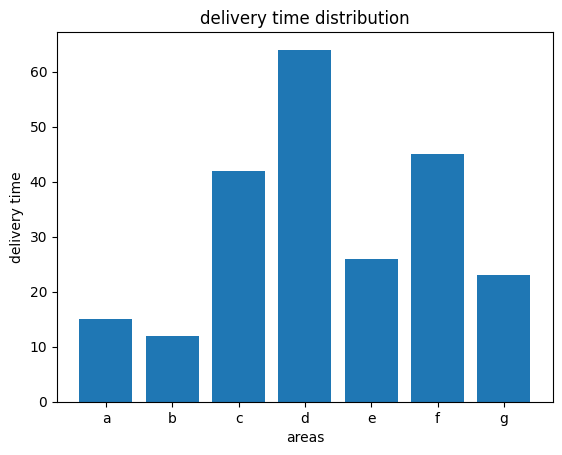

In [23]:
#charts plotting
plt.bar(df['areas'],df['delivery time'])
plt.title("delivery time distribution")
plt.xlabel("areas")
plt.ylabel("delivery time")
plt.show()

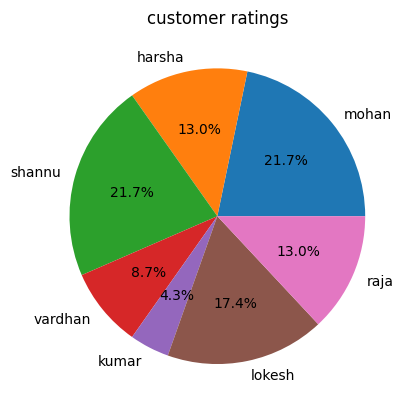

In [24]:
#pie chart based on the customer report and the delivary time that can show satisfaction
plt.pie(df['customer ratings'],labels=df['delivary partner'],autopct='%1.1f%%')
plt.title("customer ratings")
plt.show()

# Online Shopping customer Behaviour Analysis

In [71]:
#2. Online Shopping customer Behaviour Analysis
import pandas as pd
import matplotlib.pyplot as plt

df=pd.DataFrame(
    {
        "customer id":["A",'B','C','D','E','F','G','H','I','J'],
        "Product Purchase": ['laptop','phone','gas','kettle','shirt','phone','laptop','moniter','mouse','phone'],
        "cart abandonment":[['bag','mouse'],['screen guard','pouch','charger'],'cable','power socket',['pant','tie','shoe'],['screen guard','pouch','charger'],['bag','mouse'],'NA',"NA",['screen guard','pouch','charger']],
        "customer ratings":[5,2,3,5,4,5,2,3,5,1],
        "payment method": ['upi','upi','cash','net banking','upi','cash','net banking','upi','cash','net banking'],
        "spent amount":[54656,35656,545,455,650,65454,544414,5465,456,24655]
    }

)
df

,customer id,Product Purchase,cart abandonment,customer ratings,payment method,spent amount
0,A,laptop,"[bag, mouse]",5,upi,54656
1,B,phone,"[screen guard, pouch, charger]",2,upi,35656
2,C,gas,cable,3,cash,545
3,D,kettle,power socket,5,net banking,455
4,E,shirt,"[pant, tie, shoe]",4,upi,650
5,F,phone,"[screen guard, pouch, charger]",5,cash,65454
6,G,laptop,"[bag, mouse]",2,net banking,544414
7,H,moniter,NA,3,upi,5465
8,I,mouse,NA,5,cash,456
9,J,phone,"[screen guard, pouch, charger]",1,net banking,24655


In [74]:
#most sold products
most_sold_products = df['Product Purchase'].value_counts().nlargest(3)
print("\nMost Sold Products:")
print(most_sold_products)

#high revenue customers
high_revenue_customers = df.groupby('customer id')['spent amount'].sum().nlargest(3)
print("\nHigh Revenue Customers:")
print(high_revenue_customers)

#most used payment method
#most_used_payment_method = df['payment method'].value_counts().idxmax()
#print(f"\nMost Used Payment Method: {most_used_payment_method}")

most_used_payment_method = df['payment method'].mode()
print(f"\nMost Used Payment Method: {most_used_payment_method}")

#products with poor ratings
poor_rated_products = df[df['customer ratings'] < 3]['Product Purchase']
print("\nProducts with Poor Ratings:")
print(poor_rated_products)



#Prescriptive analysis



Most Sold Products:
Product Purchase
phone     3
laptop    2
gas       1
Name: count, dtype: int64

High Revenue Customers:
customer id
G    544414
F     65454
A     54656
Name: spent amount, dtype: int64

Most Used Payment Method: 0    upi
Name: payment method, dtype: object

Products with Poor Ratings:
1     phone
6    laptop
9     phone
Name: Product Purchase, dtype: object


In [49]:
#performance report
print("\nPerformance Report:")
print(df)


Performance Report:
  customer id Product Purchase                cart abandonment  \
0           A           laptop                    [bag, mouse]   
1           B            phone  [screen guard, pouch, charger]   
2           C              gas                           cable   
3           D           kettle                    power socket   
4           E            shirt               [pant, tie, shoe]   
5           F            phone  [screen guard, pouch, charger]   
6           G           laptop                    [bag, mouse]   
7           H          moniter                              NA   
8           I            mouse                              NA   
9           J            phone  [screen guard, pouch, charger]   

   customer ratings payment method  spent amount  
0                 5            upi         54656  
1                 2            upi         35656  
2                 3           cash           545  
3                 5    net banking           455

In [50]:
print("\n--- Prescriptive Analysis Recommendations ---")


#Poorly Rated Products
poor_products = df[df['customer ratings'] < 3]

print("\n--- Product Improvement Recommendations ---")
for index, row in poor_products.iterrows():
    print(f"Product '{row['Product Purchase']}' received a rating of {row['customer ratings']}.")
    print("Recommendation: Review product quality, pricing, packaging, and customer feedback.")

#High Revenue Customers
high_revenue_customers = df.groupby('customer id')['spent amount'].sum().nlargest(3)

print("\n--- Premium Customer Recommendations ---")
for customer in high_revenue_customers.index:
    print(f"Customer {customer}:")
    print("Recommendation: Provide loyalty rewards, premium membership, or exclusive discounts.")

#Payment Method Optimization
most_used_payment_method = df['payment method'].value_counts().idxmax()

print("\n--- Payment Method Recommendation ---")
print(f"Most customers prefer '{most_used_payment_method}'.")
print("Recommendation: Provide cashback offers and faster checkout options for this payment method.")

# Top Selling Products
top_products = df['Product Purchase'].value_counts().nlargest(3)

print("\n--- Inventory Recommendations ---")
for product in top_products.index:
    print(f"Product: {product}")
    print("Recommendation: Maintain sufficient stock and run promotional campaigns.")


--- Prescriptive Analysis Recommendations ---

--- Product Improvement Recommendations ---
Product 'phone' received a rating of 2.
Recommendation: Review product quality, pricing, packaging, and customer feedback.
Product 'laptop' received a rating of 2.
Recommendation: Review product quality, pricing, packaging, and customer feedback.
Product 'phone' received a rating of 1.
Recommendation: Review product quality, pricing, packaging, and customer feedback.

--- Premium Customer Recommendations ---
Customer G:
Recommendation: Provide loyalty rewards, premium membership, or exclusive discounts.
Customer F:
Recommendation: Provide loyalty rewards, premium membership, or exclusive discounts.
Customer A:
Recommendation: Provide loyalty rewards, premium membership, or exclusive discounts.

--- Payment Method Recommendation ---
Most customers prefer 'upi'.
Recommendation: Provide cashback offers and faster checkout options for this payment method.

--- Inventory Recommendations ---
Product: 

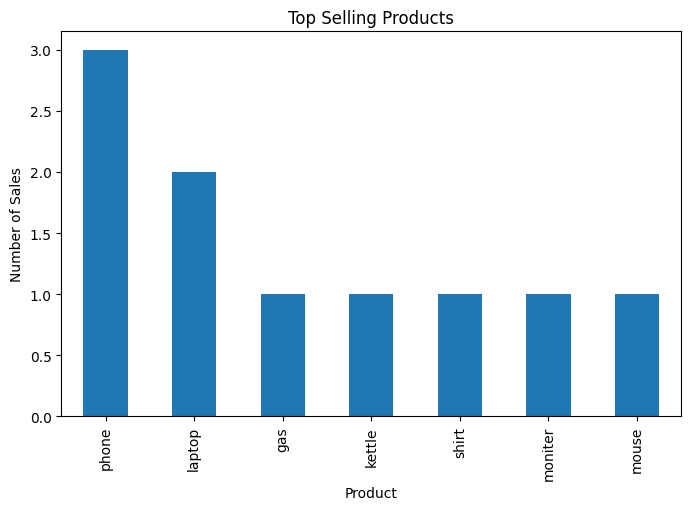

In [51]:
top_products = df['Product Purchase'].value_counts()

plt.figure(figsize=(8,5))
top_products.plot(kind='bar')
plt.title('Top Selling Products')
plt.xlabel('Product')
plt.ylabel('Number of Sales')
plt.show()

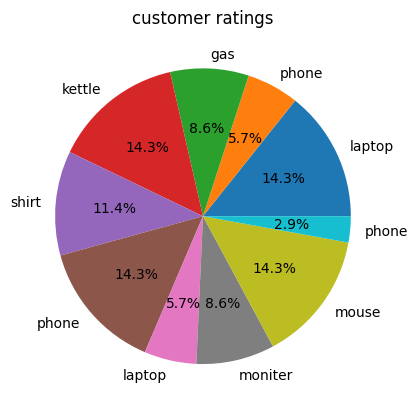

In [52]:
#pie chart
plt.pie(df['customer ratings'],labels=df['Product Purchase'],autopct='%1.1f%%')
plt.title("customer ratings")
plt.show()


# Bank Fraud Transction Detection

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

df=pd.DataFrame(
    {
        "transaction_amount":[54656,35656.98,545,455,650.435,65454,544414,5465.99,456,24655],
        "location":["A","B","C","D","E","F","G","D","I","C"],
        "time":[1,3,4,6,10,4,3,4,8,5],
        "Account_Activity":["inactive","active","active","inactive","active","inactive","inactive","active","active","inactive"]
    }
)
df

,transaction_amount,location,time,Account_Activity
0,54656.000,A,1,inactive
1,35656.980,B,3,active
2,545.000,C,4,active
3,455.000,D,6,inactive
4,650.435,E,10,active
5,65454.000,F,4,inactive
6,544414.000,G,3,inactive
7,5465.990,D,4,active
8,456.000,I,8,active
9,24655.000,C,5,inactive


In [40]:
df["Unusual_Transaction"] = df["transaction_amount"].apply(
    lambda x: "Yes" if x != int(x) else "No"
)

print(df[df["Unusual_Transaction"] == "Yes"])

   transaction_amount location  time Account_Activity Unusual_Transaction
1           35656.980        B     3           active                 Yes
4             650.435        E    10           active                 Yes
7            5465.990        D     4           active                 Yes


In [42]:
fraud_accounts = df[
    (df["transaction_amount"] % 1 != 0) |
    (df["Account_Activity"] == "inactive")
]
0
print("High Risk Accounts:")
print(fraud_accounts)

High Risk Accounts:
   transaction_amount location  time Account_Activity Unusual_Transaction
0           54656.000        A     1         inactive                  No
1           35656.980        B     3           active                 Yes
3             455.000        D     6         inactive                  No
4             650.435        E    10           active                 Yes
5           65454.000        F     4         inactive                  No
6          544414.000        G     3         inactive                  No
7            5465.990        D     4           active                 Yes
9           24655.000        C     5         inactive                  No


In [45]:
 df["Fraud_Pattern"] = df.apply(
    lambda row: "Fraud"
    if (row["transaction_amount"] % 1 != 0) or
       (row["Account_Activity"] == "inactive")
    else "Normal",
    axis=1
)

print(df)


   transaction_amount location  time Account_Activity Unusual_Transaction  \
0           54656.000        A     1         inactive                  No   
1           35656.980        B     3           active                 Yes   
2             545.000        C     4           active                  No   
3             455.000        D     6         inactive                  No   
4             650.435        E    10           active                 Yes   
5           65454.000        F     4         inactive                  No   
6          544414.000        G     3         inactive                  No   
7            5465.990        D     4           active                 Yes   
8             456.000        I     8           active                  No   
9           24655.000        C     5         inactive                  No   

  Fraud_Pattern  
0         Fraud  
1         Fraud  
2        Normal  
3         Fraud  
4         Fraud  
5         Fraud  
6         Fraud  
7       

   transaction_amount location  time
1           35656.980        B     3
4             650.435        E    10
7            5465.990        D     4


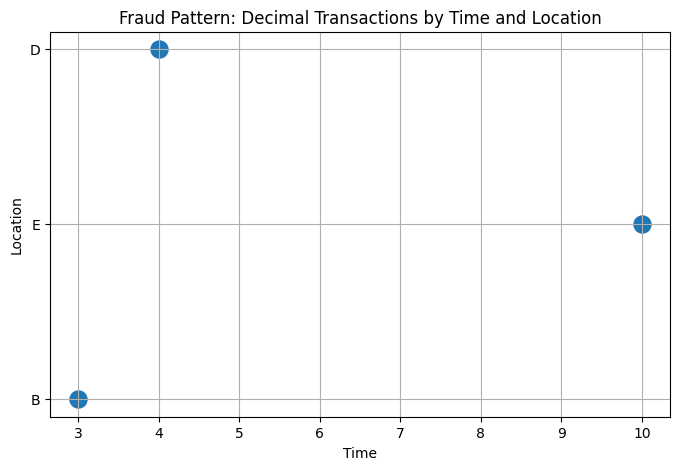

In [44]:
import matplotlib.pyplot as plt

# Decimal transactions
fraud_pattern = df[df["transaction_amount"] % 1 != 0]

print(fraud_pattern[["transaction_amount", "location", "time"]])

# Plot
plt.figure(figsize=(8,5))

plt.scatter(
    fraud_pattern["time"],
    fraud_pattern["location"],
    s=150
)

plt.xlabel("Time")
plt.ylabel("Location")
plt.title("Fraud Pattern: Decimal Transactions by Time and Location")
plt.grid(True)

plt.show()

# Flight price aPrediction

Last 10 Days Fare Data:
   Day  Fare
0    1  4200
1    2  4350
2    3  4400
3    4  4500
4    5  4600
5    6  4700
6    7  4850
7    8  4950
8    9  5100
9   10  5250

Average Fare: ₹4690.00

Daily Fare Change:
   Day  Fare  Daily_Change
0    1  4200           NaN
1    2  4350         150.0
2    3  4400          50.0
3    4  4500         100.0
4    5  4600         100.0
5    6  4700         100.0
6    7  4850         150.0
7    8  4950         100.0
8    9  5100         150.0
9   10  5250         150.0

Average Daily Increase: ₹116.67

Predicted Fare for Tomorrow: ₹5367
Prediction: Medium Demand Fare


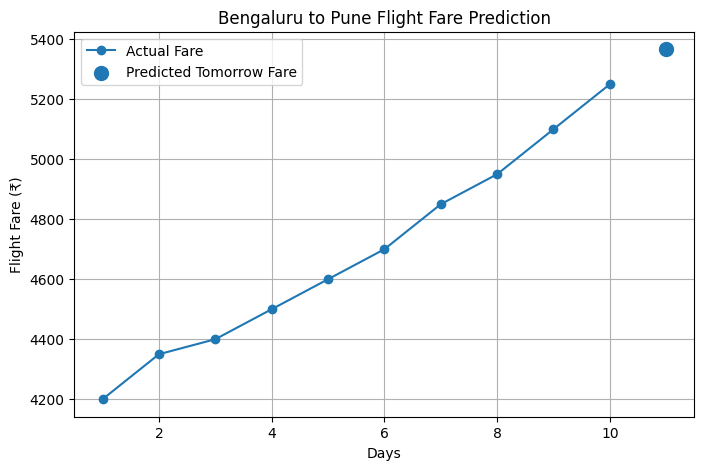

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.DataFrame(
    {
        "Day": [1,2,3,4,5,6,7,8,9,10],
        "Fare": [4200, 4350, 4400, 4500, 4600,
                 4700, 4850, 4950, 5100, 5250]
    }
)

print("Last 10 Days Fare Data:")
print(data)

# Average Fare
avg_fare = data["Fare"].mean()
print(f"\nAverage Fare: ₹{avg_fare:.2f}")

# Daily Change
data["Daily_Change"] = data["Fare"].diff()

print("\nDaily Fare Change:")
print(data)

# Average Daily Increase
avg_increase = data["Daily_Change"].mean()

print(f"\nAverage Daily Increase: ₹{avg_increase:.2f}")

# Predict Tomorrow's Fare
tomorrow_fare = data["Fare"].iloc[-1] + avg_increase

print(f"\nPredicted Fare for Tomorrow: ₹{tomorrow_fare:.0f}")

# Price Category
if tomorrow_fare > 5500:
    print("Prediction: High Demand Fare")
elif tomorrow_fare > 5000:
    print("Prediction: Medium Demand Fare")
else:
    print("Prediction: Low Demand Fare")

# Plot
plt.figure(figsize=(8,5))
plt.plot(
    data["Day"],
    data["Fare"],
    marker='o',
    label="Actual Fare"
)

plt.scatter(
    11,
    tomorrow_fare,
    s=100,
    label="Predicted Tomorrow Fare"
)

plt.xlabel("Days")
plt.ylabel("Flight Fare (₹)")
plt.title("Bengaluru to Pune Flight Fare Prediction")
plt.grid(True)
plt.legend()

plt.show()

# Super market Inventort and Sales analysis

In [66]:
import pandas as pd

df = pd.DataFrame({
    "Product_Name": [
        "Milk", "Bread", "Eggs", "Rice", "Sugar",
        "Biscuits", "Juice", "Yogurt", "Butter", "Cheese",
        "Soap", "Shampoo", "Toothpaste", "Chips", "Soft Drink"
    ],

    "Daily_Sales": [
        45, 30, 25, 12, 10,
        20, 18, 15, 8, 7,
        14, 9, 11, 22, 19
    ],

    "Stock_Available": [
        120, 80, 60, 200, 150,
        90, 70, 0, 40, 35,
        100, 65, 75, 0, 95
    ],

    "Expiry_Date": [
        "2026-06-05", "2026-06-03", "2026-06-08",
        "2027-01-15", "2027-03-20",
        "2026-12-10", "2026-09-15", "NA",
        "2026-07-01", "2026-08-12",
        "2028-01-01", "2028-03-15", "2028-05-10",
        "NA", "2026-11-25"
    ],

    "Seasonal_Demand": [
        "High","Medium", "Medium", "High", "High", "Medium", "High","Low","Medium","Low", "Medium","High","Medium","High","High"
    ]
})

df


,Product_Name,Daily_Sales,Stock_Available,Expiry_Date,Seasonal_Demand
0,Milk,45,120,2026-06-05,High
1,Bread,30,80,2026-06-03,Medium
2,Eggs,25,60,2026-06-08,Medium
3,Rice,12,200,2027-01-15,High
4,Sugar,10,150,2027-03-20,High
5,Biscuits,20,90,2026-12-10,Medium
6,Juice,18,70,2026-09-15,High
7,Yogurt,15,0,NA,Low
8,Butter,8,40,2026-07-01,Medium
9,Cheese,7,35,2026-08-12,Low


In [67]:
#fast moving products
fast_moving_products = df.nlargest(3, "Daily_Sales")
print("Fast Moving Products:")
print(fast_moving_products)

Fast Moving Products:
  Product_Name  Daily_Sales  Stock_Available Expiry_Date Seasonal_Demand
0         Milk           45              120  2026-06-05            High
1        Bread           30               80  2026-06-03          Medium
2         Eggs           25               60  2026-06-08          Medium


In [68]:
#slow moving products
slow_moving_products = df.nsmallest(3, "Daily_Sales")
print("\nSlow Moving Products:")
print(slow_moving_products)



Slow Moving Products:
   Product_Name  Daily_Sales  Stock_Available Expiry_Date Seasonal_Demand
9        Cheese            7               35  2026-08-12             Low
8        Butter            8               40  2026-07-01          Medium
11      Shampoo            9               65  2028-03-15            High


In [69]:
#out of stock
out_of_stock_products = df[df["Stock_Available"] == 0]
print("\nOut of Stock Products:")
print(out_of_stock_products)


Out of Stock Products:
   Product_Name  Daily_Sales  Stock_Available Expiry_Date Seasonal_Demand
7        Yogurt           15                0          NA             Low
13        Chips           22                0          NA            High
